In [3]:
# recreate dataset if not present
import os

if not os.path.exists("synthetic_vehicle_data.csv"):
    import numpy as np
    import pandas as pd

    np.random.seed(42)
    n = 2000

    data = pd.DataFrame({
        "engine_temp": np.random.normal(90, 10, n),
        "oil_pressure": np.random.normal(40, 5, n),
        "rpm": np.random.normal(3000, 800, n),
        "vibration": np.random.normal(0.5, 0.2, n),
        "battery_voltage": np.random.normal(12.5, 0.5, n),
        "mileage": np.random.randint(0, 200000, n)
    })

    data["failure"] = (
        (data["engine_temp"] > 110) |
        (data["oil_pressure"] < 30) |
        (data["vibration"] > 0.9) |
        (data["rpm"] > 5000)
    ).astype(int)

    data.to_csv("synthetic_vehicle_data.csv", index=False)

# now load
data = pd.read_csv("synthetic_vehicle_data.csv")

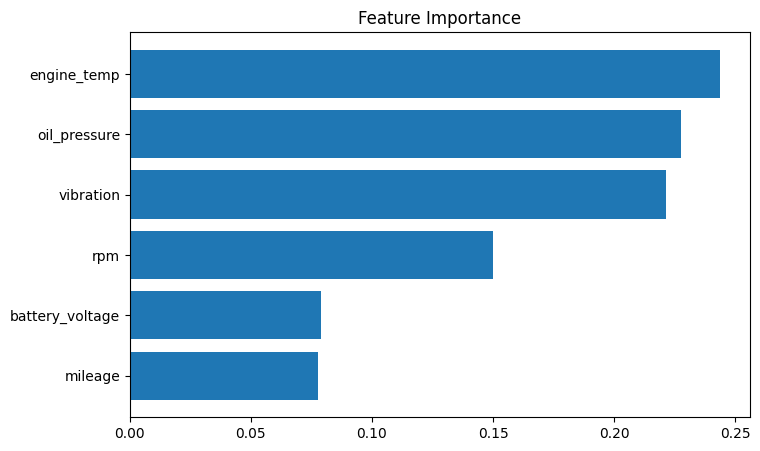

=== FINAL RESULTS ===

              precision    recall  f1-score   support

           0       0.93      0.87      0.90       874
           1       0.70      0.82      0.75       326

    accuracy                           0.85      1200
   macro avg       0.81      0.84      0.83      1200
weighted avg       0.87      0.85      0.86      1200

Confusion Matrix:

[[757 117]
 [ 58 268]]

=== THRESHOLD COMPARISON ===

Threshold: 0.2
              precision    recall  f1-score   support

           0       0.93      0.86      0.90       874
           1       0.69      0.83      0.76       326

    accuracy                           0.85      1200
   macro avg       0.81      0.85      0.83      1200
weighted avg       0.87      0.85      0.86      1200


Threshold: 0.25
              precision    recall  f1-score   support

           0       0.93      0.87      0.90       874
           1       0.71      0.82      0.76       326

    accuracy                           0.86      1200


In [5]:
# ================================
# INSTALL
# ================================
!pip install xgboost

# ================================
# IMPORTS
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier

np.random.seed(42)

# ================================
# LOAD EXISTING DATASET
# ================================
data = pd.read_csv("synthetic_vehicle_data.csv")

# ================================
# DATA AUGMENTATION (ADD MORE DATA)
# ================================
n_new = len(data)  # double dataset

new_data = pd.DataFrame({
    "engine_temp": np.random.normal(92, 12, n_new),
    "oil_pressure": np.random.normal(38, 6, n_new),
    "rpm": np.random.normal(3200, 900, n_new),
    "vibration": np.random.normal(0.55, 0.25, n_new),
    "battery_voltage": np.random.normal(12.4, 0.6, n_new),
    "mileage": np.random.randint(0, 200000, n_new)
})

# failure logic (slightly more sensitive → improves recall learning)
new_data["failure"] = (
    (new_data["engine_temp"] > 105) |
    (new_data["oil_pressure"] < 32) |
    (new_data["vibration"] > 0.8) |
    (new_data["rpm"] > 4500)
).astype(int)

# add noise
noise_idx = np.random.choice(n_new, size=int(0.1*n_new), replace=False)
new_data.loc[noise_idx, "failure"] = 1 - new_data.loc[noise_idx, "failure"]

# ================================
# COMBINE DATASETS
# ================================
data = pd.concat([data, new_data], ignore_index=True)

# ================================
# SPLIT (70 TRAIN / 30 TEST)
# ================================
X = data.drop("failure", axis=1)
y = data["failure"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# ================================
# HANDLE IMBALANCE
# ================================
scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

# ================================
# MODEL (TUNED FOR RECALL)
# ================================
model = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.03,
    scale_pos_weight=scale_pos_weight,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

# ================================
# FEATURE IMPORTANCE
# ================================
importance = model.feature_importances_
features = X.columns
indices = np.argsort(importance)

plt.figure(figsize=(8,5))
plt.barh(range(len(indices)), importance[indices])
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.title("Feature Importance")
plt.show()

# ================================
# PREDICTIONS
# ================================
y_prob = model.predict_proba(X_test)[:, 1]

# ================================
# THRESHOLD (lower = higher recall)
# ================================
threshold = 0.22
y_pred = (y_prob > threshold).astype(int)

# ================================
# RESULTS
# ================================
print("=== FINAL RESULTS ===\n")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

# ================================
# THRESHOLD COMPARISON
# ================================
print("\n=== THRESHOLD COMPARISON ===")

for t in [0.2, 0.25, 0.3, 0.4]:
    y_pred_temp = (y_prob > t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred_temp))